In [1]:
# setup
import sys
import os

sys.path.append(os.path.abspath(".."))

# ICVul
import pandas as pd

from utils.stats import run_stats

# Load the datasets
df_labels = pd.read_csv('../data/intermediate/commits_icvul.csv')
df_metrics = pd.read_csv('../data/intermediate/churn_icvul_semantic.csv')

# Merge the dataframes
df_vuln = pd.merge(
    df_labels.drop(columns=['commit_role'], errors='ignore'), 
    df_metrics, 
    on='commit_id',
    how='inner',
)

df_vuln['Dataset'] = 'Vulnerability'
df_vuln['Type'] = df_vuln['commit_role'].map({'VIC': 'Inducing', 'VFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

In [2]:
# KFC (Linux)
import pandas as pd

# Load the datasets
df_churn = pd.read_csv('../data/intermediate/churn_linux_semantic.csv')
df_labels = pd.read_csv('../data/intermediate/commits_dataset_linux.csv')

# Merge the datasets
# We drop 'commit_role' from df_churn so it doesn't conflict with df_labels
df_bug = pd.merge(
    df_labels, 
    df_churn.drop(columns=['commit_role'], errors='ignore'), 
    on='commit_id', 
    how='inner'
)

df_bug['Dataset'] = 'Bug'
df_bug['Type'] = df_bug['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

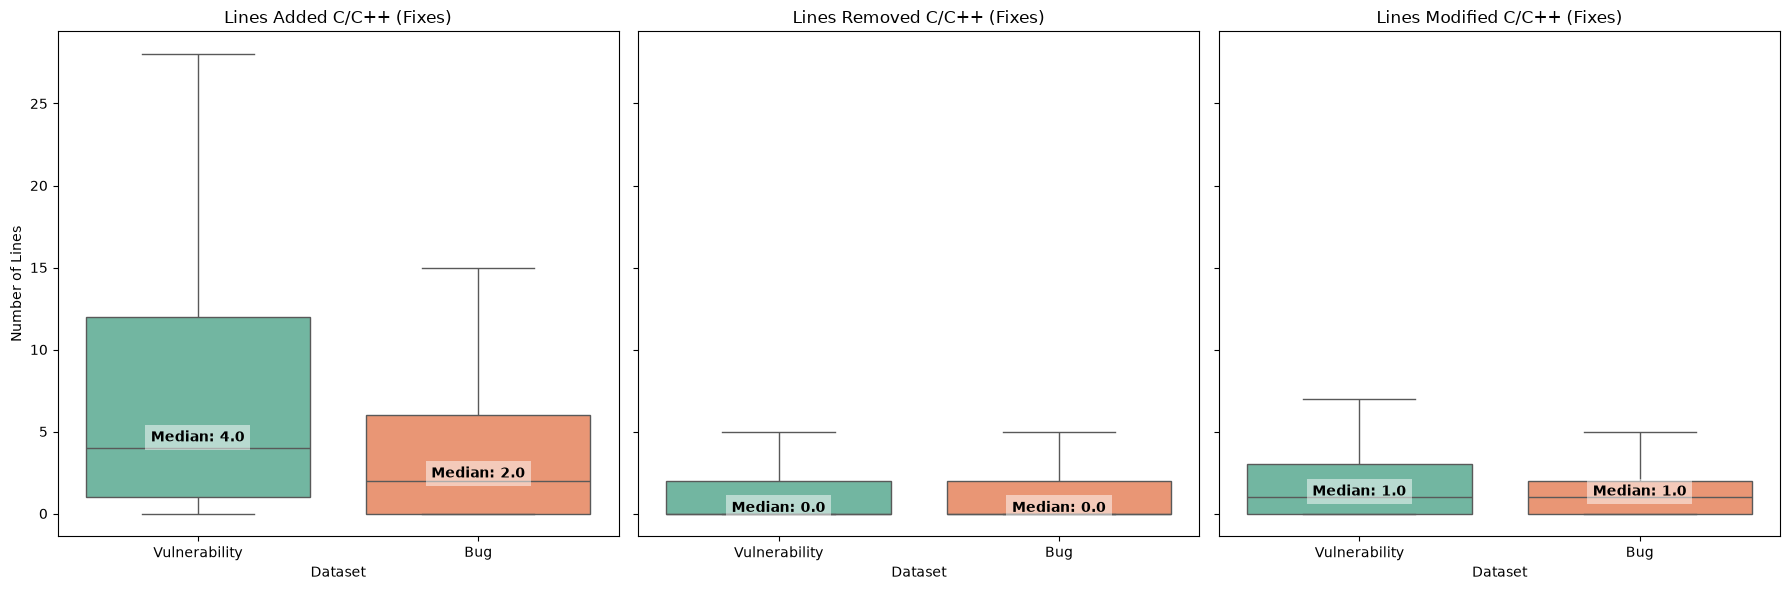


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 5.51e-197    |   0.270 (small     ) | *
Lines Removed      | 0.57872      |  -0.005 (negligible) | 
Lines Modified     | 3.87e-15     |   0.070 (negligible) | *


          Lines Added          Lines Removed          Lines Modified         
Dataset Vulnerability      Bug Vulnerability      Bug  Vulnerability      Bug
n              4230.0  64122.0        4230.0  64122.0         4230.0  64122.0
Median            4.0      2.0           0.0      0.0            1.0      1.0
Q1                1.0      0.0           0.0      0.0            0.0      0.0
Q3               12.0      6.0           2.0      2.0            3.0      2.0
Minimum           0.0      0.0           0.0      0.0            0.0      0.0
Maximum         988.0   1163.0        

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for only 'Fixing' commits (Ensure df_vuln and df_bug are your C/C++ data)
df_fixing = pd.concat([
    df_vuln[df_vuln['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[df_bug['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

# 2. Create the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added C/C++ (Fixes)', 'Lines Removed C/C++ (Fixes)', 'Lines Modified C/C++ (Fixes)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_fixing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    medians = df_fixing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'Median: {m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')

plt.tight_layout()
plt.show()

from utils.stats import run_stats, descriptive_stats_table

run_stats(df_fixing)
table = descriptive_stats_table(df_fixing)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)

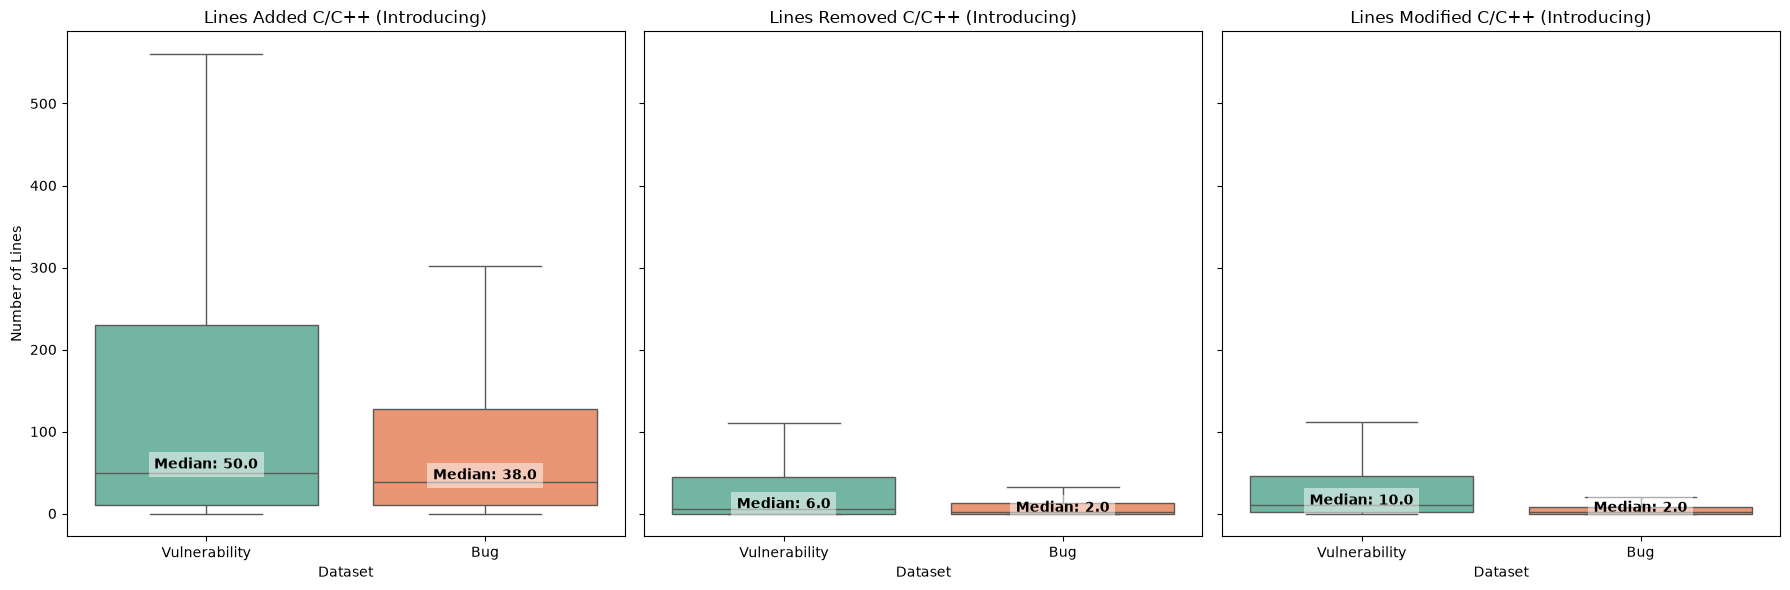


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 7.90e-35     |   0.084 (negligible) | *
Lines Removed      | 1.17e-235    |   0.216 (small     ) | *
Lines Modified     | 0.00e+00     |   0.361 (medium    ) | *


          Lines Added          Lines Removed          Lines Modified         
Dataset Vulnerability      Bug Vulnerability      Bug  Vulnerability      Bug
n              8491.0  48631.0        8491.0  48631.0         8491.0  48631.0
Median           50.0     38.0           6.0      2.0           10.0      2.0
Q1               10.0     10.0           0.0      0.0            2.0      0.0
Q3              230.0    127.0          44.0     13.0           46.0      8.0
Minimum           0.0      0.0           0.0      0.0            0.0      0.0
Maximum        9880.0   9892.0      2

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for only 'Fixing' commits (Ensure df_vuln and df_bug are your C/C++ data)
df_introducing = pd.concat([
    df_vuln[(df_vuln['commit_role'] == 'VIC') & (df_vuln['lines_added'] < 10000)][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[(df_bug['commit_role'] == 'BIC') & (df_bug['lines_added'] < 10000)][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

# 2. Create the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added C/C++ (Introducing)', 'Lines Removed C/C++ (Introducing)', 'Lines Modified C/C++ (Introducing)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_introducing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    # We calculate medians grouped by Dataset for the specific metric
    medians = df_introducing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'Median: {m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')

plt.tight_layout()
plt.show()

run_stats(df_introducing)
table = descriptive_stats_table(df_introducing)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)

In [5]:
# TOSEM
import pandas as pd

# 1. Load the manual vulnerability dataset
df_vuln_java = pd.read_csv('../data/intermediate/churn_tosem_semantic.csv')

# 2. Group by Type (VFC/VIC) and calculate stats
metrics = ['lines_added', 'lines_removed', 'lines_modified']
vuln_stats = df_vuln_java.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

df_java_vfc_only = df_vuln_java[df_vuln_java['commit_role'] == 'VFC'].copy()
df_java_vic_only = df_vuln_java[df_vuln_java['commit_role'] == 'VIC'].copy()
df_java_vfc_only['Group'] = 'Java Vulnerability (Manual)'

In [6]:
# DS_APACHE
import pandas as pd

df_bug_java = pd.read_csv('../data/intermediate/churn_ds_apache_semantic.csv')

df_bug_java['Dataset'] = 'Bug'
df_bug_java['Type'] = df_bug_java['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

df_java_bfc_only = df_bug_java[df_bug_java['commit_role'] == 'BFC'].copy()
df_java_bic_only = df_bug_java[df_bug_java['commit_role'] == 'BIC'].copy()

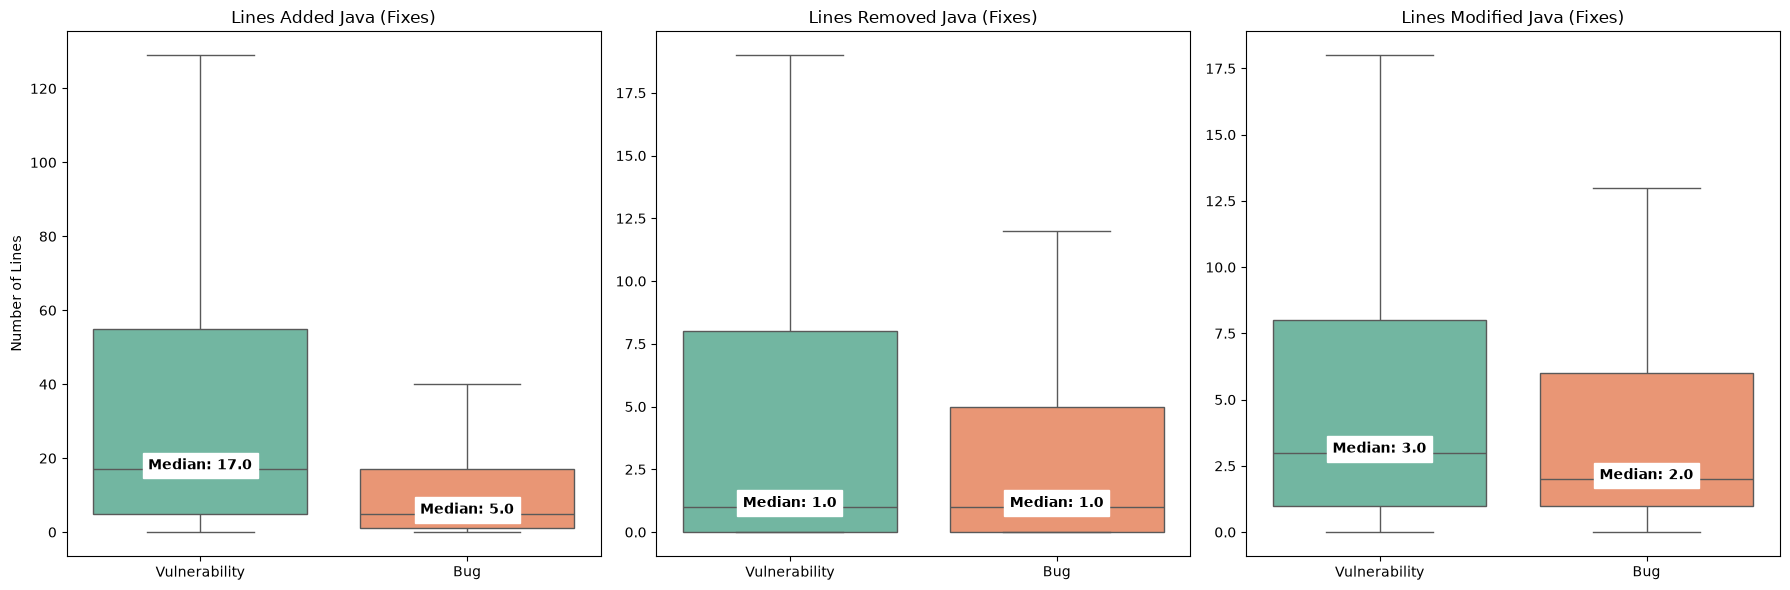


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 4.88e-09     |   0.349 (medium    ) | *
Lines Removed      | 0.85986      |  -0.010 (negligible) | 
Lines Modified     | 0.65308      |   0.027 (negligible) | 


          Lines Added        Lines Removed        Lines Modified       
Dataset Vulnerability    Bug Vulnerability    Bug  Vulnerability    Bug
n               177.0  198.0         177.0  198.0          177.0  198.0
Median           17.0    5.0           1.0    1.0            3.0    2.0
Q1                5.0    1.0           0.0    0.0            1.0    1.0
Q3               55.0   17.0           8.0    5.0            8.0    6.0
Minimum           0.0    0.0           0.0    0.0            0.0    0.0
Maximum        1714.0  823.0        1660.0  539.0          170.0  275.0


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixes
df_v = df_java_vfc_only.copy()
df_b = df_java_bfc_only.copy()

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Fixes)', 'Lines Removed Java (Fixes)', 'Lines Modified Java (Fixes)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

run_stats(df_java_comp)
table = descriptive_stats_table(df_java_comp)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)

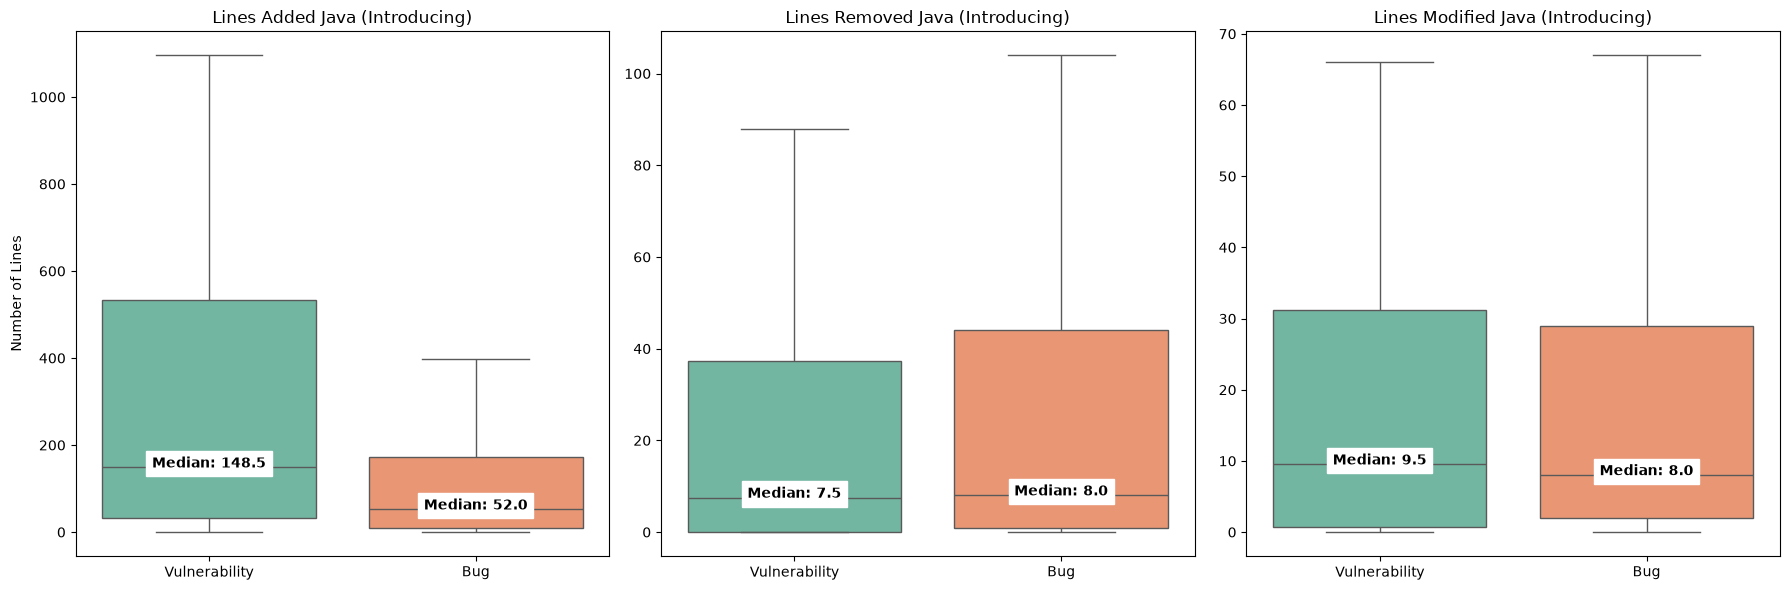


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 4.37e-05     |   0.293 (small     ) | *
Lines Removed      | 0.47718      |  -0.051 (negligible) | 
Lines Modified     | 0.38340      |  -0.062 (negligible) | 


          Lines Added         Lines Removed         Lines Modified        
Dataset Vulnerability     Bug Vulnerability     Bug  Vulnerability     Bug
n                84.0   285.0          84.0   285.0           84.0   285.0
Median          148.5    52.0           7.5     8.0            9.5     8.0
Q1               32.2    10.0           0.0     1.0            0.8     2.0
Q3              533.2   173.0          37.2    44.0           31.2    29.0
Minimum           0.0     0.0           0.0     0.0            0.0     0.0
Maximum        9388.0  7899.0       55556.0  2763.0         

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixes
df_v = df_java_vic_only.copy()
df_v = df_v[df_v['lines_added'] < 10000]
df_b = df_java_bic_only.copy()
df_b = df_b[df_b['lines_added'] < 10000]

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp_i = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Introducing)', 'Lines Removed Java (Introducing)', 'Lines Modified Java (Introducing)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp_i, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp_i.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

run_stats(df_java_comp_i)
table = descriptive_stats_table(df_java_comp_i)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)